

MANUALLY CORRECT PLIB14 samples as the subjects are _1 and _2
Same for PLib01, PLib02, PLib13, CSE01, CSE02, CSE13, CSE14, Blank01 - 08, 49 - 56




These 2 subjects D082062 and E045528 are on multiple plates. 
I think that the one of them needs to be removed from the data and manifest.

Drop these here in this script

manifest
```
D082062xxx,D082062,glioma serum,PLCO,case,73,M,15
D082062dupxxx,D082062,glioma serum,PLCO,case,73,M,15
E045528xxx,E045528,glioma serum,PLCO,case,63,M,16
E045528dupxxx,E045528,glioma serum,PLCO,case,63,M,16
```

data
```
D082062dupxxx,0,67,0,0,1,0,7,0,1,0,17,0,0,228,0,35
D082062xxx,0,2,0,0,4,0,9,0,0,0,9,0,0,0,0,0,0,7,0,1
E045528dupxxx,0,10,0,0,17,0,7,0,0,0,9,0,0,1,3,0,0,
E045528xxx,0,10,0,0,7,0,8,0,0,0,0,2,0,0,0,0,0,16,0
```


Separate the meta data

head -9 Counts.csv | datamash transpose -t, | tail -n +3 | cut -d, -f1,2,4- | sed '1isample,subject,type,study,group,age,sex,plate' | sed 's/Unnamed: [[:digit:]]\{1,2\}_level_.//g' > manifest.csv 



head -1 Counts.csv | cut -d, -f1,3- > tmp1.csv 

tail -n +10 Counts.csv | cut -d, -f1,3- >> tmp1.csv 

cat tmp1.csv | datamash transpose -t, > tmp2.csv

head -1 tmp2.csv > data.csv

tail -n +2 tmp2.csv | sort -t, -k1,1 >> data.csv

sed -i '1s/^id/sample/' data.csv


Just a matrix with peptide ids and sample ids.

drop the blanks and phage library samples

In [1]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
manifest = pd.read_csv('manifest.csv')
manifest = manifest[~manifest['sample'].isin(['D082062xxx','D082062dupxxx','E045528xxx','E045528dupxxx'])]

CPU times: user 1.97 s, sys: 352 ms, total: 2.32 s
Wall time: 2.76 s


In [2]:
manifest.shape

(1145, 8)

In [3]:
# Show the first few rows of each to inspect structure
manifest.head()


,sample,subject,type,study,group,age,sex,plate
0,14078-01,14078-01,glioma serum,IPS,case,60.0,M,1
1,14078-01dup,14078-01,glioma serum,IPS,case,60.0,M,1
2,14118-01,14118-01,glioma serum,IPS,case,61.0,M,1
3,14118-01dup,14118-01,glioma serum,IPS,case,61.0,M,1
4,14127-01,14127-01,glioma serum,IPS,case,63.0,M,1


In [4]:
%%time

data = pd.read_csv('data.csv')
data = data[~data['sample'].isin(['D082062xxx','D082062dupxxx','E045528xxx','E045528dupxxx'])]

CPU times: user 1min 17s, sys: 2.7 s, total: 1min 20s
Wall time: 1min 20s


In [5]:
data.shape

(1145, 115293)

In [6]:
data.head()


,sample,1,2,3,4,5,6,7,8,9,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
0,024JCM,0,0,0,0,1,0,53,0,0,...,0,0,0,0,1,0,0,0,2,0
1,024JCMdup,0,2,0,0,44,0,3,0,0,...,3,0,1,193,0,0,0,0,2,0
2,043MPL,0,20,0,0,23,0,31,0,0,...,0,0,0,20,6,4,0,4,3,0
3,043MPLdup,0,16,0,0,10,0,4,0,0,...,7,0,3,4,13,8,0,0,7,0
4,074KBP,0,0,0,0,31,0,52,0,18,...,0,0,0,0,0,0,1,0,39,7


In [7]:
# Use only relevant columns from manifest
manifest = manifest[['sample', 'subject', 'plate']]

# Classify samples based on sample/subject prefix
def classify_sample(row):
    if row['sample'].startswith('CSE') or row['subject'].startswith('CSE'):
        return 'control'
    elif row['sample'].startswith('Blank') or row['subject'].startswith('Blank'):
        return 'blank'
    elif row['sample'].startswith('PLib') or row['subject'].startswith('PLib'):
        return 'phage_library'
    else:
        return 'subject'

manifest['class'] = manifest.apply(classify_sample, axis=1)

# Align data: keep only samples present in both manifest and data
samples_in_both = set(manifest['sample']).intersection(set(data['sample']))
manifest = manifest[manifest['sample'].isin(samples_in_both)].reset_index(drop=True)
data = data[data['sample'].isin(samples_in_both)].reset_index(drop=True)

# Fill missing values in data with 0
data = data.fillna(0)

# Set sample as index for easier manipulation
data.set_index('sample', inplace=True)

# Merge manifest info into data for easy access
data_annot = data.copy()
data_annot['plate'] = data_annot.index.map(manifest.set_index('sample')['plate'])
data_annot['class'] = data_annot.index.map(manifest.set_index('sample')['class'])

# Show class distribution and a few rows
manifest['class'].value_counts(), data_annot.head()

(class
 subject          1004
 blank              93
 control            24
 phage_library      24
 Name: count, dtype: int64,
            1   2  3  4   5  6   7  8   9  10  ...  128280  128281  128282  \
 sample                                        ...                           
 024JCM     0   0  0  0   1  0  53  0   0   0  ...       0       0       1   
 024JCMdup  0   2  0  0  44  0   3  0   0   0  ...       1     193       0   
 043MPL     0  20  0  0  23  0  31  0   0   0  ...       0      20       6   
 043MPLdup  0  16  0  0  10  0   4  0   0   0  ...       3       4      13   
 074KBP     0   0  0  0  31  0  52  0  18   0  ...       0       0       0   
 
            128283  128284  128285  128286  128287  plate    class  
 sample                                                             
 024JCM          0       0       0       2       0     14  subject  
 024JCMdup       0       0       0       2       0     14  subject  
 043MPL          4       0       4       3       

In [8]:
import numpy as np

# Prepare for blank subtraction
data_blank_sub = data.copy()
data_blank_sub.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0,0,0,0,1,0,53,0,0,0,...,0,0,0,0,1,0,0,0,2,0
024JCMdup,0,2,0,0,44,0,3,0,0,0,...,3,0,1,193,0,0,0,0,2,0
043MPL,0,20,0,0,23,0,31,0,0,0,...,0,0,0,20,6,4,0,4,3,0
043MPLdup,0,16,0,0,10,0,4,0,0,0,...,7,0,3,4,13,8,0,0,7,0
074KBP,0,0,0,0,31,0,52,0,18,0,...,0,0,0,0,0,0,1,0,39,7


In [9]:
# my addition to avoid type warning
data_blank_sub = data_blank_sub.astype('float64')
data_blank_sub.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.0,0.0,0.0,1.0,0.0,53.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
024JCMdup,0.0,2.0,0.0,0.0,44.0,0.0,3.0,0.0,0.0,0.0,...,3.0,0.0,1.0,193.0,0.0,0.0,0.0,0.0,2.0,0.0
043MPL,0.0,20.0,0.0,0.0,23.0,0.0,31.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20.0,6.0,4.0,0.0,4.0,3.0,0.0
043MPLdup,0.0,16.0,0.0,0.0,10.0,0.0,4.0,0.0,0.0,0.0,...,7.0,0.0,3.0,4.0,13.0,8.0,0.0,0.0,7.0,0.0
074KBP,0.0,0.0,0.0,0.0,31.0,0.0,52.0,0.0,18.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39.0,7.0


In [10]:
%%time

# For each plate, subtract the median blank counts per peptide
for plate in manifest['plate'].unique():
    # Get blank samples for this plate
    blank_samples = manifest[(manifest['plate'] == plate) & (manifest['class'] == 'blank')]['sample']
    if len(blank_samples) == 0:
        continue  # skip if no blanks
    # Median blank counts for each peptide
    blank_median = data.loc[blank_samples].median(axis=0)
    # Subtract from all samples on this plate
    plate_samples = manifest[manifest['plate'] == plate]['sample']
    
    data_blank_sub.loc[plate_samples] = np.maximum(
        data.loc[plate_samples].values - blank_median.values, 0
    )

CPU times: user 4.95 s, sys: 422 ms, total: 5.38 s
Wall time: 5.37 s


In [11]:
# Add plate/class info for plotting
data_blank_sub_annot = data_blank_sub.copy()
data_blank_sub_annot['plate'] = data_blank_sub_annot.index.map(manifest.set_index('sample')['plate'])
data_blank_sub_annot['class'] = data_blank_sub_annot.index.map(manifest.set_index('sample')['class'])

# Show a few rows after blank subtraction
data_blank_sub_annot.head()

,1,2,3,4,5,6,7,8,9,10,...,128280,128281,128282,128283,128284,128285,128286,128287,plate,class
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.0,0.0,0.0,0.0,0.0,53.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,14,subject
024JCMdup,0.0,2.0,0.0,0.0,43.0,0.0,3.0,0.0,0.0,0.0,...,1.0,193.0,0.0,0.0,0.0,0.0,2.0,0.0,14,subject
043MPL,0.0,20.0,0.0,0.0,22.0,0.0,30.0,0.0,0.0,0.0,...,0.0,20.0,6.0,2.0,0.0,4.0,3.0,0.0,13,subject
043MPLdup,0.0,16.0,0.0,0.0,9.0,0.0,3.0,0.0,0.0,0.0,...,3.0,4.0,13.0,6.0,0.0,0.0,7.0,0.0,13,subject
074KBP,0.0,0.0,0.0,0.0,30.0,0.0,52.0,0.0,18.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,39.0,7.0,14,subject


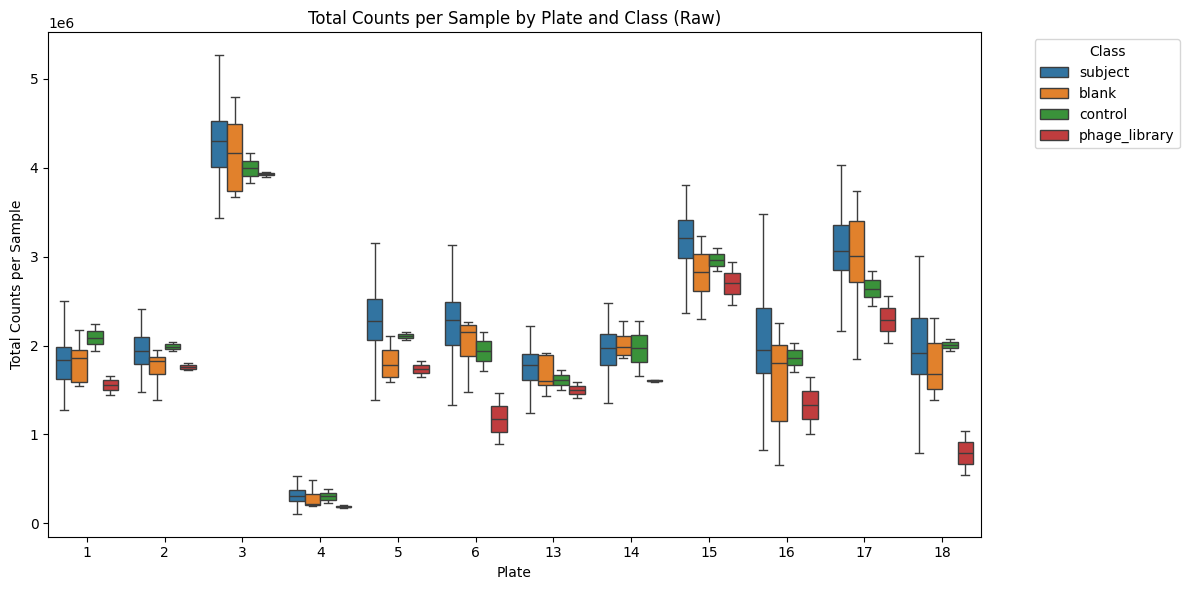

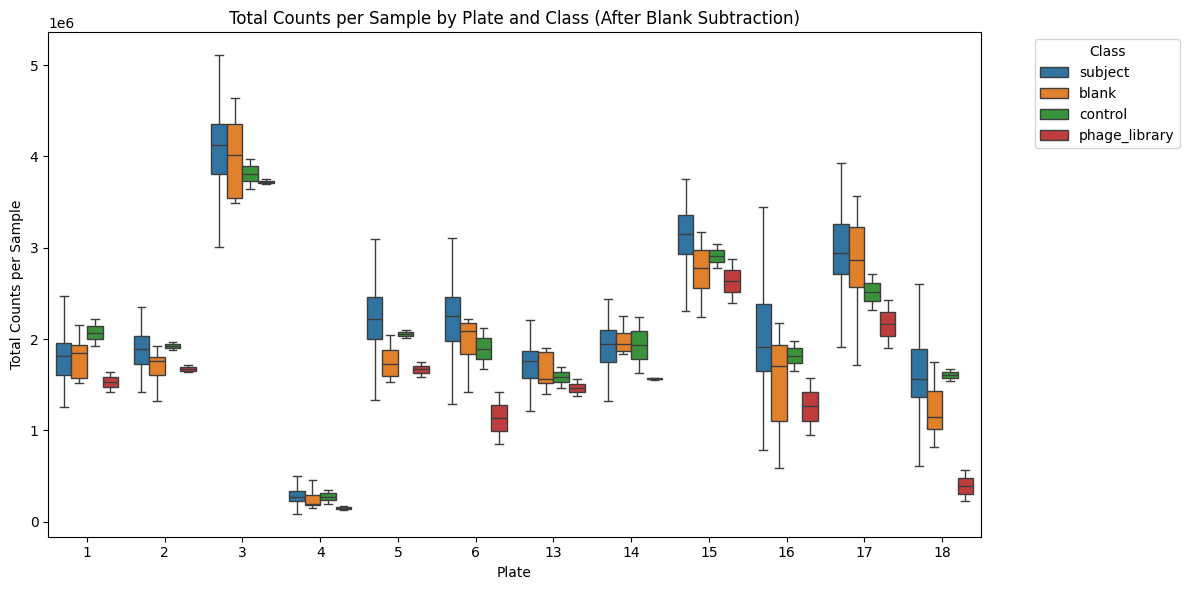

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_total_counts(data_annot, title):
    # Calculate total counts per sample
    total_counts = data_annot.drop(['plate', 'class'], axis=1).sum(axis=1)
    plot_df = pd.DataFrame({
        'total_counts': total_counts,
        'plate': data_annot['plate'],
        'class': data_annot['class']
    })
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='plate', y='total_counts', hue='class', data=plot_df, showfliers=False)
    plt.title(title)
    plt.ylabel('Total Counts per Sample')
    plt.xlabel('Plate')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Before blank subtraction
plot_total_counts(data_annot, "Total Counts per Sample by Plate and Class (Raw)")

# After blank subtraction
plot_total_counts(data_blank_sub_annot, "Total Counts per Sample by Plate and Class (After Blank Subtraction)")

In [13]:
# select ONLY the subjects and maybe the controls.
# drop the blanks and phage library
# my addition to avoid type warning

data_blank_sub_drop_blanks_and_plib = data_annot[data_annot['class'].isin(['control','subject'])]
data_blank_sub_drop_blanks_and_plib = data_blank_sub_drop_blanks_and_plib.drop(['class','plate'],axis='columns')
data_blank_sub_drop_blanks_and_plib = data_blank_sub_drop_blanks_and_plib.astype('float64')

# data_blank_sub_drop_blanks_and_plib
# probably need a manifest_drop_blanks_and_plib as well

In [14]:
data_blank_sub_drop_blanks_and_plib.shape

(1028, 115292)

In [15]:
manifest.shape

(1145, 4)

In [16]:
manifest_drop_blanks_and_plib = manifest[manifest['class'].isin(['control','subject'])]
manifest_drop_blanks_and_plib.shape

(1028, 4)

In [17]:
manifest.shape

(1145, 4)

In [18]:
%%time

from sklearn.preprocessing import quantile_transform

# Function to quantile normalize within each plate
def quantile_normalize_within_plate(data, manifest):
    data_qn = data.copy()
    for plate in manifest['plate'].unique():
        plate_samples = manifest[manifest['plate'] == plate]['sample']
        plate_data = data_qn.loc[plate_samples]
        # Only normalize if more than 1 sample
        if plate_data.shape[0] > 1:
            # Quantile normalization (output values are floats)
            qn = quantile_transform(plate_data, axis=0, n_quantiles=min(1000, plate_data.shape[0]), copy=True, output_distribution='uniform')
            data_qn.loc[plate_samples] = qn
    return data_qn

# Apply quantile normalization after blank subtraction
#data_qn = quantile_normalize_within_plate(data_blank_sub, manifest)


#data_qn = quantile_normalize_within_plate(data_blank_sub_drop_blanks_and_plib, manifest)
data_qn = quantile_normalize_within_plate(data_blank_sub_drop_blanks_and_plib, manifest_drop_blanks_and_plib)



CPU times: user 2min 12s, sys: 638 ms, total: 2min 12s
Wall time: 2min 13s


In [19]:
# combat does not like matrices with values 0-1
# the output turns out to be the exact same as the imput
# using 100 as it hopefully matches the approximate current scale of raw data
data_qn = data_qn * 100

In [20]:
data_qn.max().max()

np.float64(100.0)

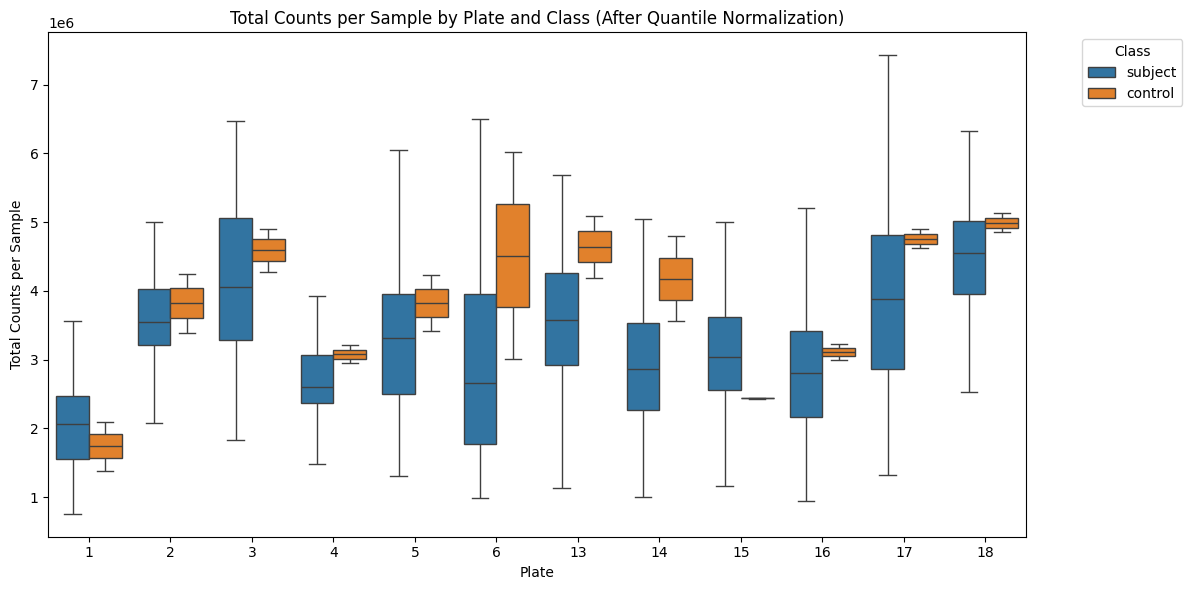

In [21]:
# Add plate/class info for plotting
data_qn_annot = data_qn.copy()
data_qn_annot['plate'] = data_qn_annot.index.map(manifest.set_index('sample')['plate'])
data_qn_annot['class'] = data_qn_annot.index.map(manifest.set_index('sample')['class'])

# Plot total counts after quantile normalization
plot_total_counts(data_qn_annot, "Total Counts per Sample by Plate and Class (After Quantile Normalization)")

In [22]:
# Prepare data for ComBat: pycombat_seq expects samples as columns, features as rows
from inmoose.pycombat import pycombat_seq

# Remove annotation columns for ComBat
#combat_input = data_scaled.copy()
combat_input = data_qn.copy()
combat_input = combat_input.astype(float)  # ensure float for pycombat_seq
combat_input_T = combat_input.T  # features as rows, samples as columns

In [23]:
# Plate batch vector
batch_vector = manifest.set_index('sample').loc[combat_input_T.columns]['plate'].values


In [24]:
batch_vector

array([14, 14, 13, ..., 14, 13, 13], shape=(1028,))

In [25]:
combat_input_T

sample,024JCM,024JCMdup,043MPL,043MPLdup,074KBP,074KBPdup,101VKC,101VKCdup,108741,108741dup,...,P391XQG,P391XQGdup,P414AIK,P414AIKdup,P422DSR,P422DSRdup,P429EMJ,P429EMJdup,P432CUD,P432CUDdup
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,68.823529,76.470588,70.588235,0.000000,0.000000,0.0,37.647059,74.096386,0.000000,...,58.235294,0.000000,76.470588,96.470588,0.000000,96.470588,72.941176,85.294118,37.647059,47.058824
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,97.647059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,25.294118,78.823529,65.882353,45.294118,72.941176,49.411765,0.0,26.470588,48.795181,58.433735,...,18.823529,88.235294,58.823529,72.352941,0.000000,44.117647,56.470588,95.294118,0.000000,87.058824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128283,0.000000,0.000000,75.294118,88.823529,0.000000,95.294118,0.0,70.000000,82.530120,94.578313,...,0.000000,0.000000,88.823529,0.000000,0.000000,91.764706,0.000000,0.000000,0.000000,0.000000
128284,0.000000,0.000000,0.000000,0.000000,81.176471,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,81.176471,0.000000,94.117647,0.000000,0.000000,0.000000
128285,0.000000,0.000000,82.352941,0.000000,0.000000,82.352941,0.0,0.000000,0.000000,0.000000,...,0.000000,61.176471,97.647059,100.000000,0.000000,0.000000,0.000000,0.000000,82.352941,61.176471
128286,68.823529,68.823529,65.294118,80.588235,97.647059,82.941176,0.0,75.294118,80.120482,83.132530,...,86.470588,65.294118,0.000000,75.294118,73.529412,98.823529,0.000000,0.000000,0.000000,100.000000


In [26]:
%%time

# I think that 
# [WARNING] library size of zero detected
# just means that 1 column or maybe 1 row has a sum of 0

# https://github.com/epigenelabs/inmoose/blob/060afb2c8abcae509bc4d86f45082066835df1ab/inmoose/edgepy/DGEList.py#L145
# lib_size = counts.sum(axis=0)
# lib_size = np.asarray(lib_size)
# minlibsize = np.min(lib_size)
# if minlibsize == 0:
#     if np.logical_and(lib_size == 0, (counts.sum(axis=0) > 0)).any():
#         raise ValueError("library size set to zero but counts are nonzero")
#     LOGGER.warning("library size of zero detected")

# pycombat appears to like integers. It may round off floats resulting if half the data becoming 0


#combat_corrected = pycombat_seq(data_qn.copy().astype(float).T, batch_vector)

combat_corrected = pycombat_seq(combat_input_T, batch_vector)


CPU times: user 21min 52s, sys: 3min 26s, total: 25min 19s
Wall time: 22min 59s


In [27]:
print(combat_corrected.equals(combat_input_T))

False


In [29]:
combat_input_T.max().max()
#np.float64(1.0)

np.float64(100.0)

In [30]:
#data_blank_sub_drop_blanks_and_plib.max().max()
#np.float64(644681.0)

In [31]:
combat_corrected.max().max()
#np.float64(23314179.0)

np.float64(1796.0)

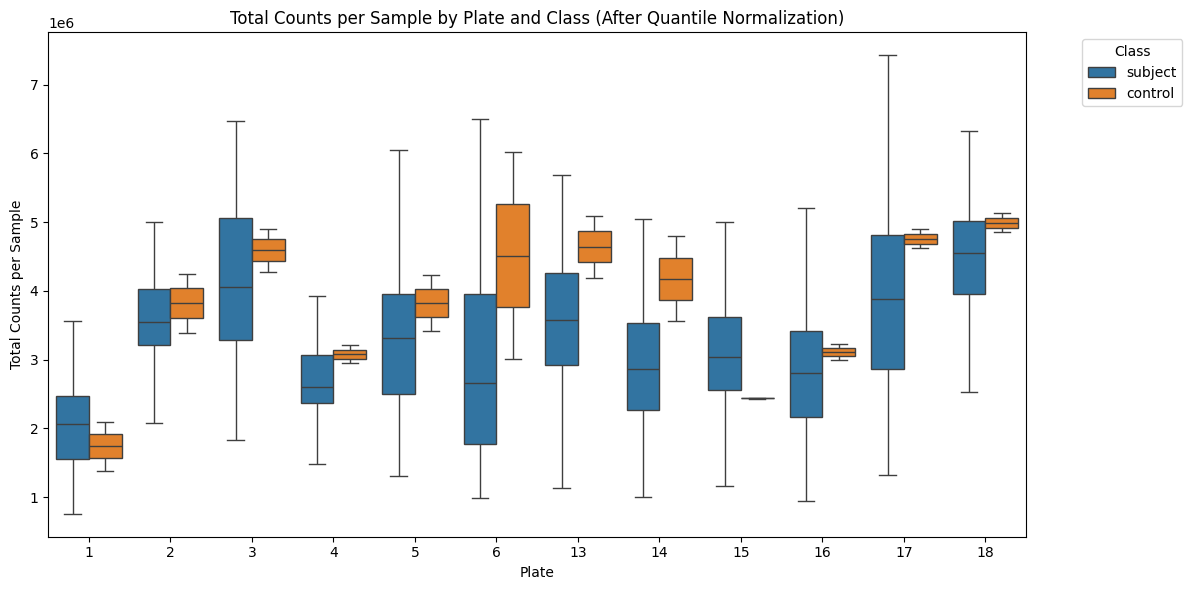

In [47]:
plot_total_counts(data_qn_annot, "Total Counts per Sample by Plate and Class (After Quantile Normalization)")

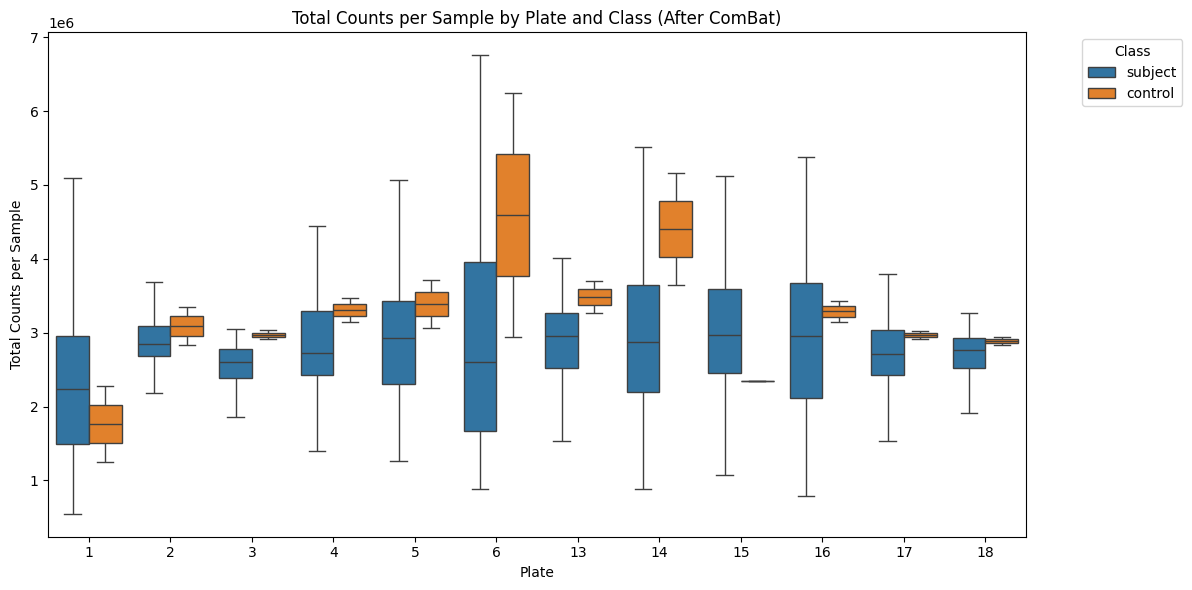

In [33]:
# Transpose back to samples as rows
data_combat = pd.DataFrame(combat_corrected, index=combat_input_T.index, columns=combat_input_T.columns).T

# Add plate/class info for plotting
data_combat_annot = data_combat.copy()
data_combat_annot['plate'] = data_combat_annot.index.map(manifest.set_index('sample')['plate'])
data_combat_annot['class'] = data_combat_annot.index.map(manifest.set_index('sample')['class'])

# Plot total counts after ComBat
plot_total_counts(data_combat_annot, "Total Counts per Sample by Plate and Class (After ComBat)")

In [35]:
# Map sample to subject
sample_to_subject = manifest.set_index('sample')['subject']

# Group by subject and take mean across replicates
## this skips data_combat????
#data_scaled['subject'] = data_scaled.index.map(sample_to_subject)
#data_final = data_scaled.groupby('subject').mean()

data_combat['subject'] = data_combat.index.map(sample_to_subject)
data_final = data_combat.groupby('subject').mean()

# Show a few rows of the final merged data
data_final.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,46.5,0.0,0.0,49.0,0.0,62.5,0.0,0.0,0.0,...,53.0,0.0,24.5,45.5,12.5,0.0,0.0,0.0,69.5,0.0
043MPL,0.0,75.0,0.0,0.0,58.5,0.0,37.0,0.0,0.0,0.0,...,42.5,0.0,12.0,47.0,35.0,65.5,0.0,18.5,77.5,0.0
074KBP,0.0,0.0,0.0,0.0,59.0,0.0,90.5,0.0,35.0,0.0,...,0.0,0.0,0.0,0.0,27.5,81.0,39.0,41.0,93.0,144.5
101VKC,0.0,17.0,0.0,0.0,13.0,0.0,37.5,0.0,0.0,0.0,...,49.0,0.0,23.0,35.0,51.5,28.5,0.0,0.0,40.5,16.0
108741,0.0,32.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,...,120.0,0.0,0.0,75.5,31.0,73.5,0.0,0.0,86.5,130.0


In [36]:
def compute_control_cv(data_annot, manifest):
    # Get control samples
    control_samples = manifest[manifest['class'] == 'control']['sample']
    if len(control_samples) == 0:
        return np.nan
    # Total counts per control sample
    total_counts = data_annot.loc[control_samples].drop(['plate', 'class'], axis=1).sum(axis=1)
    cv = total_counts.std() / total_counts.mean()
    return cv

cv_raw = compute_control_cv(data_annot, manifest)
cv_blank = compute_control_cv(data_blank_sub_annot, manifest)
cv_qn = compute_control_cv(data_qn_annot, manifest)
#cv_scaled = compute_control_cv(data_scaled_annot, manifest)
cv_combat = compute_control_cv(data_combat_annot, manifest)

cv_results = pd.DataFrame({
#    'Step': ['Raw', 'Blank Subtraction', 'Quantile Norm', 'Phage Lib Scaling', 'Combat'],
#    'Control CV': [cv_raw, cv_blank, cv_qn, cv_scaled, cv_combat]
    'Step': ['Raw', 'Blank Subtraction', 'Quantile Norm', 'Combat'],
    'Control CV': [cv_raw, cv_blank, cv_qn, cv_combat]
})

# What to look for: CV should decrease after normalization. Target CV < 0.2 for controls.

cv_results

,Step,Control CV
0,Raw,0.404821
1,Blank Subtraction,0.411270
2,Quantile Norm,0.298873
3,Combat,0.296413


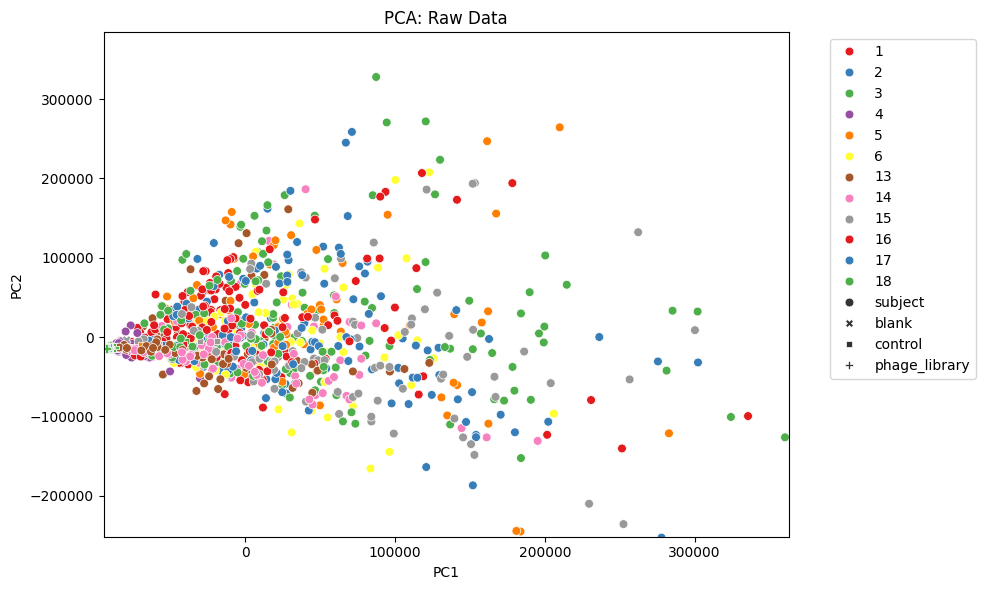

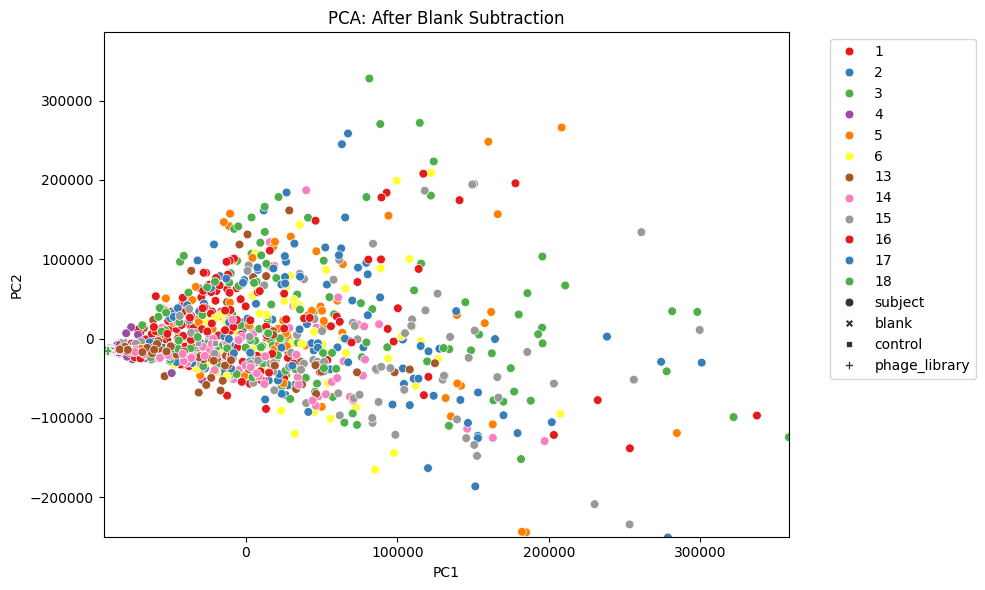

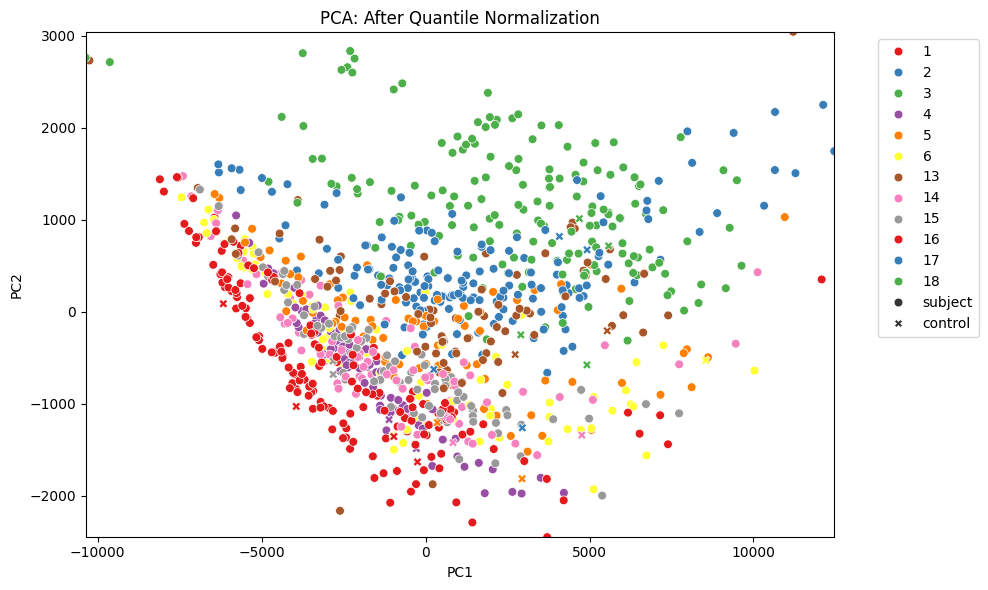

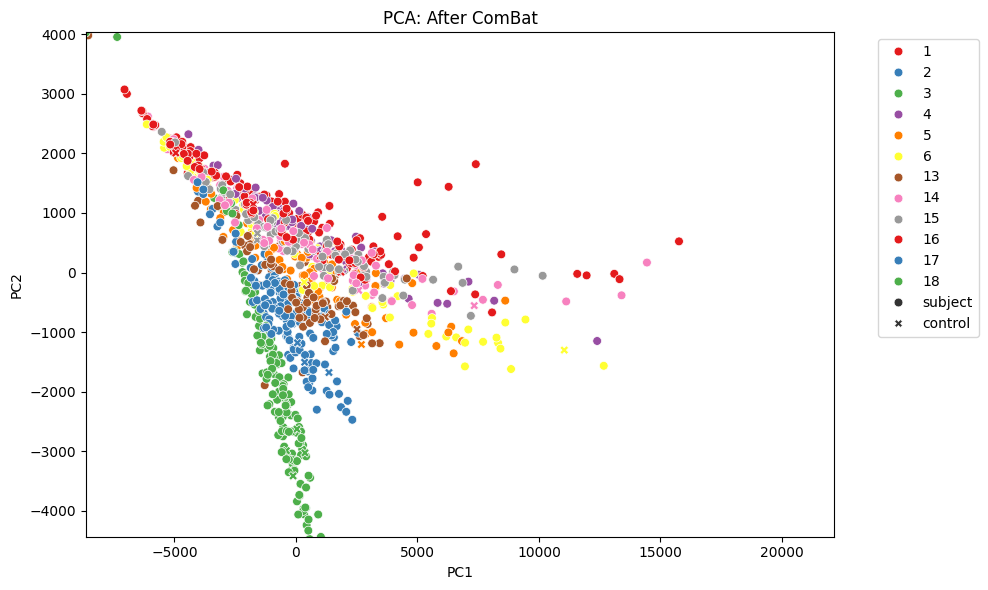

In [46]:
from sklearn.decomposition import PCA

def plot_pca(data_annot, manifest, title):
    # Remove annotation columns
    X = data_annot.drop(['plate', 'class'], axis=1).values
    y = data_annot['class'].values
    plates = data_annot['plate'].values
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(10, 6))

    # ignore 0.2% of the points in the plot (there is a single very, very stray point in the combat plot)
    x_min, x_max = np.percentile(X_pca[:, 0], [0.1, 99.9])
    y_min, y_max = np.percentile(X_pca[:, 1], [0.1, 99.9])
    #sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=plates, s=80, palette='Set1')
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=plates, style=y, s=40, palette='Set1')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# PCA plots for each step
plot_pca(data_annot, manifest, "PCA: Raw Data")
plot_pca(data_blank_sub_annot, manifest, "PCA: After Blank Subtraction")
plot_pca(data_qn_annot, manifest, "PCA: After Quantile Normalization")
#plot_pca(data_scaled_annot, manifest, "PCA: After Phage Library Scaling")
plot_pca(data_combat_annot, manifest, "PCA: After ComBat")

In [38]:
data_final

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,46.5,0.000000,0.0,49.0,0.0,62.5,0.0,0.0,0.0,...,53.0,0.0,24.5,45.5,12.5,0.0,0.0,0.0,69.5,0.0
043MPL,0.0,75.0,0.000000,0.0,58.5,0.0,37.0,0.0,0.0,0.0,...,42.5,0.0,12.0,47.0,35.0,65.5,0.0,18.5,77.5,0.0
074KBP,0.0,0.0,0.000000,0.0,59.0,0.0,90.5,0.0,35.0,0.0,...,0.0,0.0,0.0,0.0,27.5,81.0,39.0,41.0,93.0,144.5
101VKC,0.0,17.0,0.000000,0.0,13.0,0.0,37.5,0.0,0.0,0.0,...,49.0,0.0,23.0,35.0,51.5,28.5,0.0,0.0,40.5,16.0
108741,0.0,32.0,0.000000,0.0,43.0,0.0,0.0,0.0,0.0,0.0,...,120.0,0.0,0.0,75.5,31.0,73.5,0.0,0.0,86.5,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P391XQG,0.0,29.5,48.823529,0.0,58.0,0.0,39.0,0.0,0.0,16.0,...,48.0,11.5,23.0,44.0,112.5,0.0,0.0,13.0,81.5,34.0
P414AIK,0.0,89.5,0.000000,0.0,69.0,0.0,49.5,0.0,0.0,11.0,...,77.0,15.5,13.0,42.5,13.5,35.0,0.0,46.5,40.0,24.5
P422DSR,0.0,61.5,0.000000,0.0,22.5,0.0,67.5,0.0,0.0,65.5,...,63.0,0.0,25.0,79.0,32.0,77.5,39.0,0.0,88.5,66.0


In [39]:
#subject_manifest = manifest.drop('sample',axis='columns').sort_values(by='subject').drop_duplicates()
subject_manifest = manifest_drop_blanks_and_plib.drop('sample',axis='columns').sort_values(by='subject').drop_duplicates()
subject_manifest = subject_manifest.set_index('subject')
subject_manifest

,plate,class
subject,,
024JCM,14,subject
043MPL,13,subject
074KBP,14,subject
101VKC,13,subject
108741,16,subject
...,...,...
P391XQG,13,subject
P414AIK,13,subject
P422DSR,14,subject


In [40]:
df=pd.DataFrame(subject_manifest.index)
df[df.duplicated()]

#these 2 are duplicated on different plates making this complicated.
# for this I should probably remove them from the dataset on the second plates
#	    subject
#520	D082062
#533	E045528

,subject


In [41]:
data_final_annot = subject_manifest.join(data_final)
data_final_annot

,plate,class,1,2,3,4,5,6,7,8,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,14,subject,0.0,46.5,0.000000,0.0,49.0,0.0,62.5,0.0,...,53.0,0.0,24.5,45.5,12.5,0.0,0.0,0.0,69.5,0.0
043MPL,13,subject,0.0,75.0,0.000000,0.0,58.5,0.0,37.0,0.0,...,42.5,0.0,12.0,47.0,35.0,65.5,0.0,18.5,77.5,0.0
074KBP,14,subject,0.0,0.0,0.000000,0.0,59.0,0.0,90.5,0.0,...,0.0,0.0,0.0,0.0,27.5,81.0,39.0,41.0,93.0,144.5
101VKC,13,subject,0.0,17.0,0.000000,0.0,13.0,0.0,37.5,0.0,...,49.0,0.0,23.0,35.0,51.5,28.5,0.0,0.0,40.5,16.0
108741,16,subject,0.0,32.0,0.000000,0.0,43.0,0.0,0.0,0.0,...,120.0,0.0,0.0,75.5,31.0,73.5,0.0,0.0,86.5,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P391XQG,13,subject,0.0,29.5,48.823529,0.0,58.0,0.0,39.0,0.0,...,48.0,11.5,23.0,44.0,112.5,0.0,0.0,13.0,81.5,34.0
P414AIK,13,subject,0.0,89.5,0.000000,0.0,69.0,0.0,49.5,0.0,...,77.0,15.5,13.0,42.5,13.5,35.0,0.0,46.5,40.0,24.5
P422DSR,14,subject,0.0,61.5,0.000000,0.0,22.5,0.0,67.5,0.0,...,63.0,0.0,25.0,79.0,32.0,77.5,39.0,0.0,88.5,66.0


In [42]:
from sklearn.metrics import silhouette_score

# Want LOW silhouette score when clustering by plate
# Want HIGH silhouette score when clustering by biology
score_plate = silhouette_score(data_final, data_final_annot['plate'])
score_biology = silhouette_score(data_final, data_final_annot['class'])   # not sure if this is even helpful

print(f"Silhouette score (plate): {score_plate:.3f}")  # Should be close to 0 ( How close? Is -0.083 "close"?
print(f"Silhouette score (biology): {score_biology:.3f}")  # Should be positive ( How positive? -0.010 isn't positive. )

Silhouette score (plate): -0.083
Silhouette score (biology): 0.017


In [43]:

score_plate = silhouette_score(data, data_annot['plate'])
score_biology = silhouette_score(data, data_annot['class'])   # not sure if this is even helpful

print(f"Silhouette score (plate): {score_plate:.3f}")  # Should be close to 0 ( How close? Is -0.083 "close"?
print(f"Silhouette score (biology): {score_biology:.3f}")  # Should be positive ( How positive? -0.010 isn't positive. )

Silhouette score (plate): -0.201
Silhouette score (biology): -0.292
